# Recuperación y Desenvolvimiento de Fase Óptica
En este notebook analizaremos cómo recuperar la fase de un frente de onda simulado utilizando Phase Shifting de 4 pasos y posteriormente aplicaremos algoritmos de desenvolvimiento (unwrapping) para obtener la fase continua.

In [2]:
# Importación de librerías y módulos propios
import numpy as np
import matplotlib.pyplot as plt

# Módulos matemáticos encapsulados
from franjas import SimuladorFranjas
from Metodos_desenvolvedores_de_fase import ProcesadorFase

# Configuración visual para el notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 6)

## 1. Simulación y Adquisición de Datos
Generamos un vórtice óptico (espiral) y simulamos la captura de 4 interferogramas con un desfase de $\pi/2$. Esto simula lo que recibiríamos en el laboratorio al sincronizar una cámara con un modulador espacial o un piezoeléctrico.

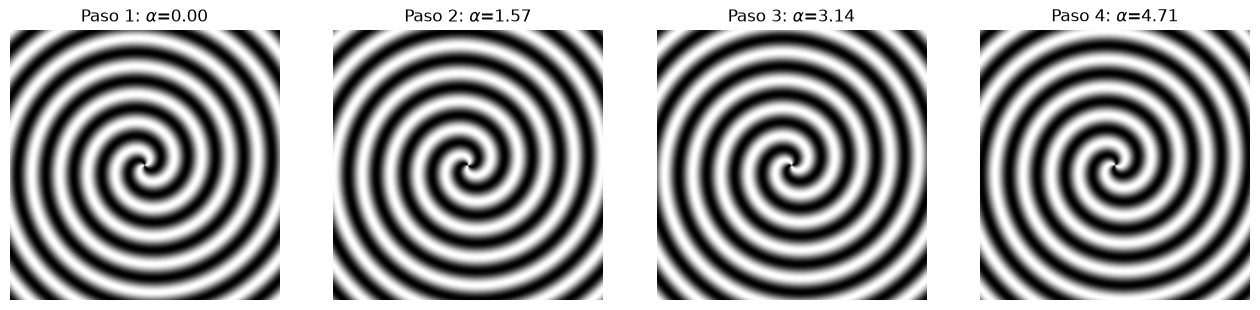

In [3]:
# Inicializamos el hardware simulado
simulador = SimuladorFranjas(resolucion=512, I_obj=0.7, I_ref=0.3)

# Generamos el cubo de datos (4 imágenes)
stack_I, alphas = simulador.generar_stack_phase_shifting(
    tipo_fase='espiral', 
    pasos=4, 
    k=30, m=2
)

# Visualización de los patrones capturados
fig, axes = plt.subplots(1, 4)
for i in range(4):
    axes[i].imshow(stack_I[i], cmap='gray')
    axes[i].set_title(f'Paso {i+1}: $\\alpha$={alphas[i]:.2f}')
    axes[i].axis('off')
plt.show()

## 2. Extracción y Desenvolvimiento
Utilizamos la ecuación trigonométrica inversa para hallar la fase envuelta $\Delta \phi$ acotada en $[-\pi, \pi)$. Finalmente, aplicamos los algoritmos de desenvolvimiento para remover los saltos de fase.

Error: scikit-image no está instalado. Retornando None.


<>:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/m0/p3fptypn0tn8sf4m4n8634bw0000gn/T/ipykernel_47356/255384178.py:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0].set_title('Fase Envuelta $[-\pi, \pi)$')


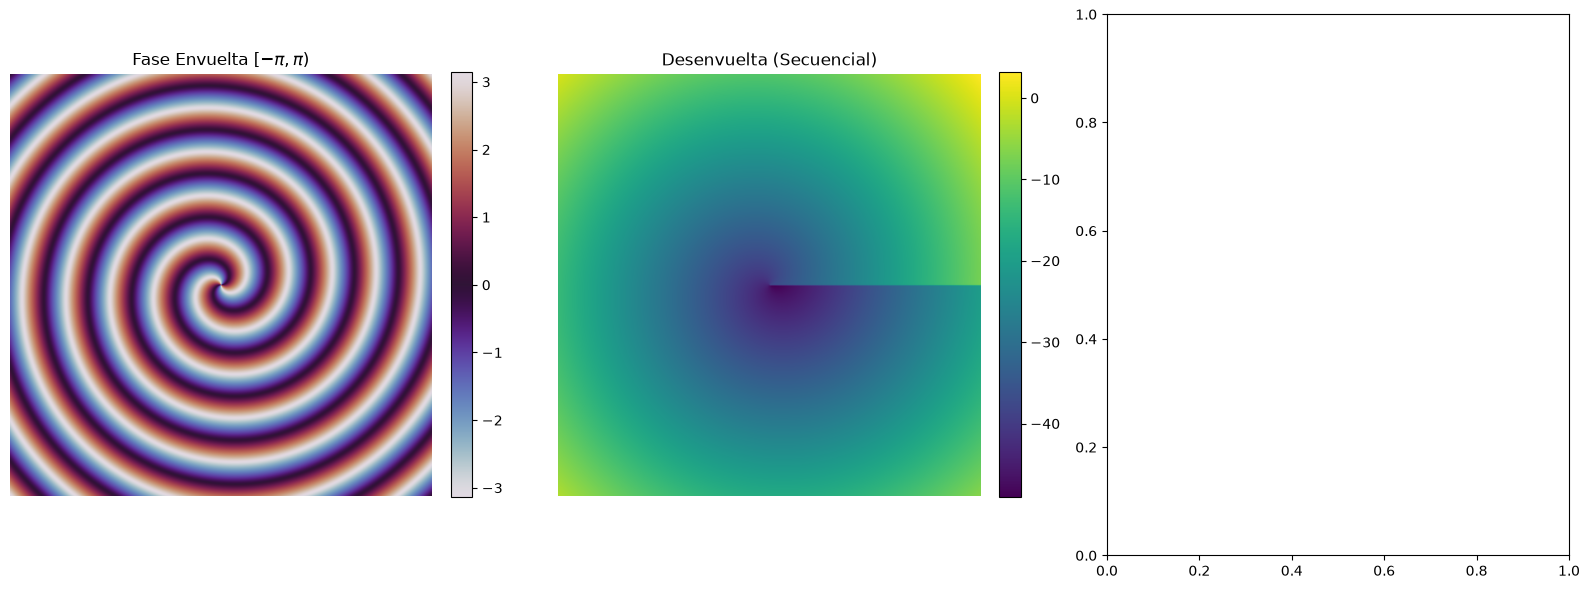

In [ ]:
# Inicializamos el procesador
procesador = ProcesadorFase()

# A. Extraer fase envuelta
fase_envuelta = procesador.phase_shifting_4_pasos(stack_I)

# B. Aplicar desenvolvimiento
fase_continua_itoh = procesador.desenvolvimiento_basico(fase_envuelta)
fase_continua_robusta = procesador.desenvolvimiento_robusto(fase_envuelta)

# C. Visualizar el pipeline completo
fig, axes = plt.subplots(1, 3)

# Mapa 1: Fase envuelta
im1 = axes[0].imshow(fase_envuelta, cmap='twilight')
# CORRECCIÓN: Agregamos la 'r' antes de la cadena de texto
axes[0].set_title(r'Fase Envuelta $[-\pi, \pi)$')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Mapa 2: Fase desenvuelta (Itoh)
im2 = axes[1].imshow(fase_continua_itoh, cmap='viridis')
axes[1].set_title('Desenvuelta (Secuencial)')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Mapa 3: Fase desenvuelta (Robusta)
if fase_continua_robusta is not None:
    im3 = axes[2].imshow(fase_continua_robusta, cmap='viridis')
    axes[2].set_title('Desenvuelta (Robusta - skimage)')
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()